# Análisis Cuantitativo de Dependencias y Vulnerabilidades

Este notebook consolida y analiza los SBOMs y los escaneos de vulnerabilidades generados para múltiples repositorios activos de la organización `anomalyco`.

In [1]:
import json
import glob
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar visualización
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

## 1. Análisis de Dependencias (SBOMs)

Cargamos localmente todos los registros JSON de SBOM generados por [Syft] para cuantificar e inspeccionar las dependencias presentes en cada repositorio.

In [2]:
ruta_resultados = Path('../data/results/')
archivos_sbom = list(ruta_resultados.glob('*-sbom.json'))

datos_dependencias = []

for archivo in archivos_sbom:
    repo_name = archivo.name.replace('-sbom.json', '')
    with open(archivo, 'r', encoding='utf-8') as f:
        data = json.load(f)
        artefactos = data.get('artifacts', [])
        
        for artef in artefactos:
            datos_dependencias.append({
                'repositorio': repo_name,
                'nombre': artef.get('name'),
                'version': artef.get('version'),
                'tipo': artef.get('type')
            })

df_deps = pd.DataFrame(datos_dependencias)
print(f"Total de dependencias encontradas: {len(df_deps)}")

Total de dependencias encontradas: 7969


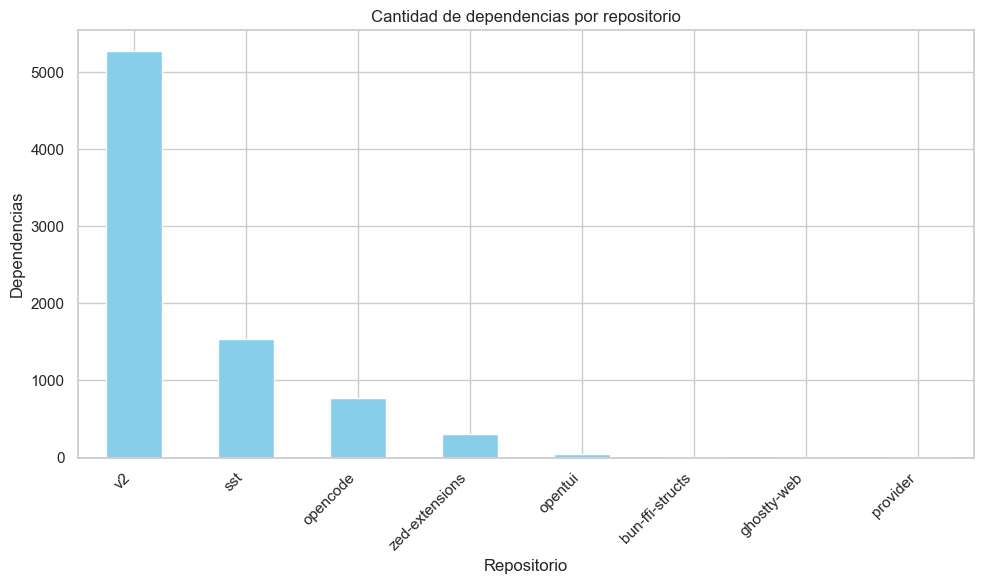

In [3]:
# Top repositorios por cantidad de dependencias
conteo_repo = df_deps['repositorio'].value_counts()
plt.figure(figsize=(10, 6))
conteo_repo.plot(kind='bar', color='skyblue')
plt.title('Cantidad de dependencias por repositorio')
plt.xlabel('Repositorio')
plt.ylabel('Dependencias')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

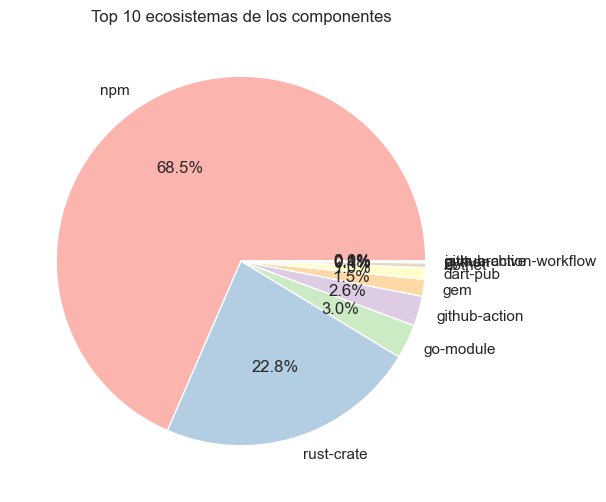

In [4]:
# Ecosistemas de las dependencias
conteo_ecosistemas = df_deps['tipo'].value_counts().head(10)
plt.figure(figsize=(10, 6))
conteo_ecosistemas.plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1')
plt.title('Top 10 ecosistemas de los componentes')
plt.ylabel('')
plt.show()

## 2. Análisis de Vulnerabilidades (Grype)

A continuación cargamos y consolidamos los resultados de los análisis hechos con el escáner Grype, los cuales identifican vulnerabilidades (CVEs) explícitas en las librerías importadas.

In [5]:
archivos_grype = list(ruta_resultados.glob('*-grype.json'))
datos_vulns = []

for archivo in archivos_grype:
    repo_name = archivo.name.replace('-grype.json', '')
    with open(archivo, 'r', encoding='utf-8') as f:
        data = json.load(f)
        vulnerabilidades = data.get('vulnerabilities', [])
        
        for vuln in vulnerabilidades:
            # Grype severity comes in downcase, adapt it to capitalized.
            datos_vulns.append({
                'repositorio': repo_name,
                'paquete': vuln.get('package_name'),
                'id_vuln': vuln.get('vuln_id'),
                'severidad': str(vuln.get('vuln_severity')).capitalize(),
                'puntuacion_cvss': vuln.get('cvss_score', 0)
            })

df_vulns = pd.DataFrame(datos_vulns)
print(f"Total de vulnerabilidades detectadas: {len(df_vulns)}")

Total de vulnerabilidades detectadas: 7


C:\Users\belen\AppData\Local\Temp\ipykernel_16248\4290994592.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_vulns, x='severidad', order=['Critical', 'High', 'Medium', 'Low'], palette='Reds_r')


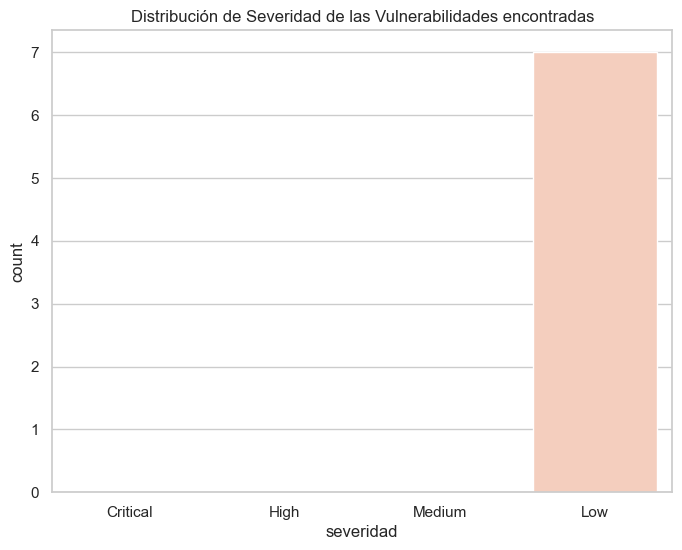

In [6]:
# Resumen de severidad general
if not df_vulns.empty:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df_vulns, x='severidad', order=['Critical', 'High', 'Medium', 'Low'], palette='Reds_r')
    plt.title('Distribución de Severidad de las Vulnerabilidades encontradas')
    plt.show()

### Vulnerabilidades de Riesgo (Críticas / Altas)

In [7]:
if not df_vulns.empty:
    df_criticas = df_vulns[df_vulns['severidad'].isin(['Critical', 'High'])]
    conteo_criticas = df_criticas.groupby(['repositorio', 'severidad']).size().unstack(fill_value=0)
    
    if not conteo_criticas.empty:
        conteo_criticas.plot(kind='bar', stacked=True, figsize=(10,6), colormap='autumn')
        plt.title('Vulnerabilidades Críticas y Altas por Repositorio')
        plt.ylabel('Cantidad')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("No se hallaron vulnerabilidades críticas o altas en los repositorios escaneados.")

No se hallaron vulnerabilidades críticas o altas en los repositorios escaneados.


## 3. Conclusiones

A través de este enfoque de automatización multi-etapa se vislumbra el riesgo subyacente presente en los diversos repositorios de la organización. Mantener trazabilidad de SBOMs y emplear métodos cuantitativos ayuda inmensamente en el ecosistema DevOps moderno para el triaje temprano de deudas técnicas referidas a Componentes de Software Abierto (SCA).